In [63]:
import numpy as np
import pandas as pd

In [64]:
df = pd.read_csv('/content/placement.csv')

In [65]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [66]:
df = df.iloc[:,1:]

In [67]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [68]:
df.shape

(100, 3)

##### STEPS

##### 1.Preprocess + EDA + Feature Selection
##### 2.Extract input and output cols
##### 3.Scale the values
##### 4.Train test split
##### 5.Train the model
##### 6.Evaluate the model/model selection
##### 7.Deploy the model

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [70]:
df.describe()

,cgpa,iq,placement
count,100.000000,100.000000,100.000000
mean,5.991000,123.580000,0.500000
std,1.143634,39.944198,0.502519
min,3.300000,37.000000,0.000000
25%,5.075000,101.500000,0.000000
50%,6.000000,127.500000,0.500000
75%,6.900000,149.000000,1.000000
max,8.500000,233.000000,1.000000


In [71]:
%pip install matplotlib

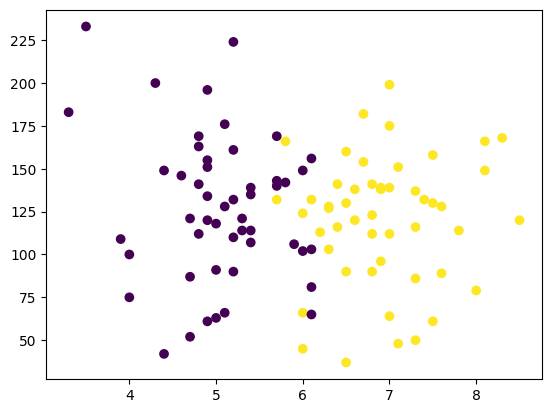

In [72]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'],df['iq'],c = df['placement'])
#yellow = placed

In [73]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [74]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [75]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [88]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2)

In [89]:
X_train

,cgpa,iq
38,6.5,160.0
30,7.6,128.0
94,4.7,52.0
54,6.4,141.0
64,7.0,64.0
...,...,...
33,6.0,149.0
50,3.5,233.0
20,6.6,120.0
17,3.3,183.0


In [90]:
X_test

,cgpa,iq
21,7.1,151.0
9,5.1,66.0
98,6.3,103.0
16,5.2,224.0
84,5.7,169.0
36,5.7,140.0
69,8.5,120.0
32,7.0,139.0
71,6.1,132.0
53,8.3,168.0


In [91]:
y_train

,placement
38,1
30,1
94,0
54,1
64,1
...,...
33,0
50,0
20,1
17,0


In [92]:
y_test

,placement
21,1
9,0
98,1
16,0
84,0
36,0
69,1
32,1
71,1
53,1


In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [94]:
X_train_scaled

array([[ 0.51531494,  1.01601307],
       [ 1.49053462,  0.19265332],
       [-1.08049907, -1.7628261 ],
       [ 0.42665861,  0.52714322],
       [ 0.95859661, -1.45406619],
       [ 1.22456562, -0.88800636],
       [ 0.69262761,  1.58207291],
       [-1.16915541,  0.65579318],
       [-1.34646808, -2.02012603],
       [ 1.49053462, -0.81081638],
       [ 0.42665861, -0.11610659],
       [-0.6372174 , -0.27048654],
       [-0.9031864 ,  0.34703327],
       [-1.70109341, -1.17103628],
       [ 1.93381629,  0.73298316],
       [ 0.33800227,  0.19265332],
       [-0.19393573,  0.5786032 ],
       [ 1.22456562,  0.42422325],
       [ 0.95859661,  1.40196296],
       [ 1.40187828, -1.53125617],
       [ 0.07203327, -0.47632648],
       [ 0.07203327, -1.40260621],
       [ 1.31322195,  0.29557329],
       [-1.43512441,  2.04521277],
       [-1.34646808,  0.73298316],
       [ 0.16068961, -1.4283362 ],
       [-0.19393573,  0.29557329],
       [ 1.22456562, -1.81428609],
       [-0.45990473,

In [95]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train,y_train)


LogisticRegression()

In [96]:
y_pred = clf.predict(X_test)
y_pred

array([1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1])

In [97]:
y_test

,placement
21,1
9,0
98,1
16,0
84,0
36,0
69,1
32,1
71,1
53,1


In [98]:
from sklearn.metrics import accuracy_score

In [99]:
accuracy_score(y_test,y_pred)

0.95

In [100]:
from mlxtend.plotting import plot_decision_regions

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


<Axes: >

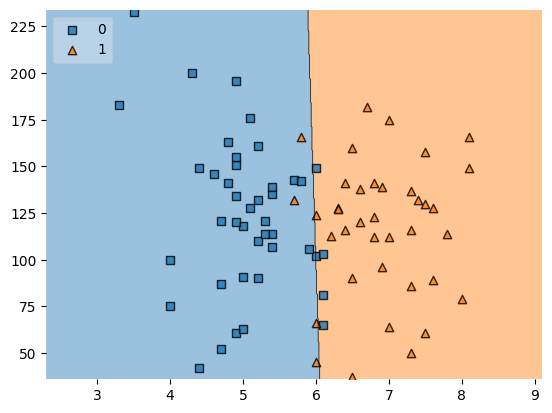

In [102]:
plot_decision_regions(X_train.values, y_train.values, clf=clf, legend=2)

In [103]:
import pickle

In [104]:
pickle.dump(clf,open('model.pkl','wb'))